# Shailesh Gowtham V - 24BAD108

In [6]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error


import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
movies = pd.read_csv('/kaggle/input/datasets/ayushimishra2809/movielens-dataset/movies.csv')
ratings = pd.read_csv('/kaggle/input/datasets/ayushimishra2809/movielens-dataset/ratings.csv')

ratings = ratings[['userId', 'movieId', 'rating']]

In [8]:
user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')

In [9]:
user_means = user_item_matrix.mean(axis=1)

matrix_centered = user_item_matrix.sub(user_means, axis=0)
matrix_centered = matrix_centered.fillna(0)

In [10]:
U, sigma, Vt = np.linalg.svd(matrix_centered, full_matrices=False)

In [11]:
k = 50

U_k = U[:, :k]
sigma_k = np.diag(sigma[:k])
Vt_k = Vt[:k, :]

In [12]:
reconstructed = np.dot(np.dot(U_k, sigma_k), Vt_k)

# Add mean back
reconstructed += user_means.values.reshape(-1, 1)

reconstructed_df = pd.DataFrame(
    reconstructed,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

In [13]:
actual = user_item_matrix.values
predicted = reconstructed_df.values

# Mask only existing ratings
mask = ~np.isnan(actual)

y_true = actual[mask]
y_pred = predicted[mask]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 0.6219322272028106
MAE: 0.4013151450526372


In [14]:
def recommend_movies(user_id, n=10):
    user_ratings = user_item_matrix.loc[user_id]
    user_pred = reconstructed_df.loc[user_id]

    unseen = user_ratings[user_ratings.isna()].index

    recommendations = user_pred[unseen].sort_values(ascending=False)

    return movies[movies['movieId'].isin(recommendations.head(n).index)]

recommend_movies(1, 10)

,movieId,title,genres
5,6,Heat (1995),Action|Crime|Thriller
744,923,Citizen Kane (1941),Drama|Mystery
745,924,2001: A Space Odyssey (1968),Adventure|Drama|Sci-Fi
956,1193,One Flew Over the Cuckoo's Nest (1975),Drama
962,1200,Aliens (1986),Action|Adventure|Horror|Sci-Fi
975,1214,Alien (1979),Horror|Sci-Fi
1050,1291,Indiana Jones and the Last Crusade (1989),Action|Adventure
1843,2329,American History X (1998),Crime|Drama
3322,4226,Memento (2000),Mystery|Thriller
7669,58559,"Dark Knight, The (2008)",Action|Crime|Drama|IMAX


In [15]:
ks = [10, 20, 50, 100]
rmse_list = []

for k in ks:
    U_k = U[:, :k]
    sigma_k = np.diag(sigma[:k])
    Vt_k = Vt[:k, :]

    recon = np.dot(np.dot(U_k, sigma_k), Vt_k)
    recon += user_means.values.reshape(-1, 1)

    pred = recon

    y_pred = pred[mask]
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    rmse_list.append(rmse)

print(list(zip(ks, rmse_list)))

[(10, np.float64(0.7948105989154658)), (20, np.float64(0.7387907071918867)), (50, np.float64(0.6219322272028106)), (100, np.float64(0.49120384036613973))]


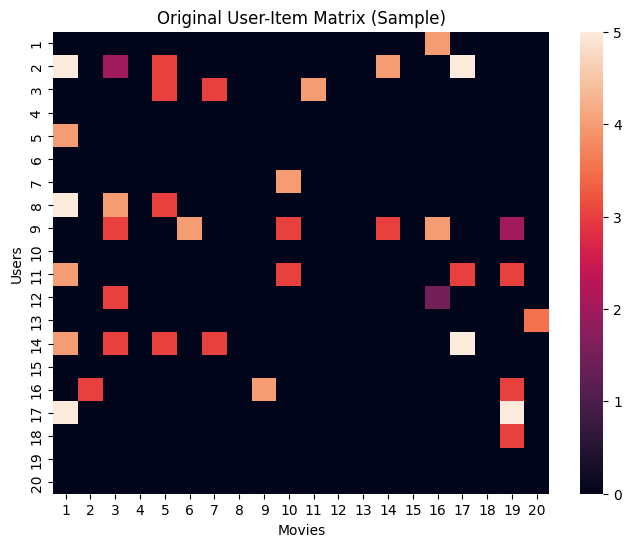

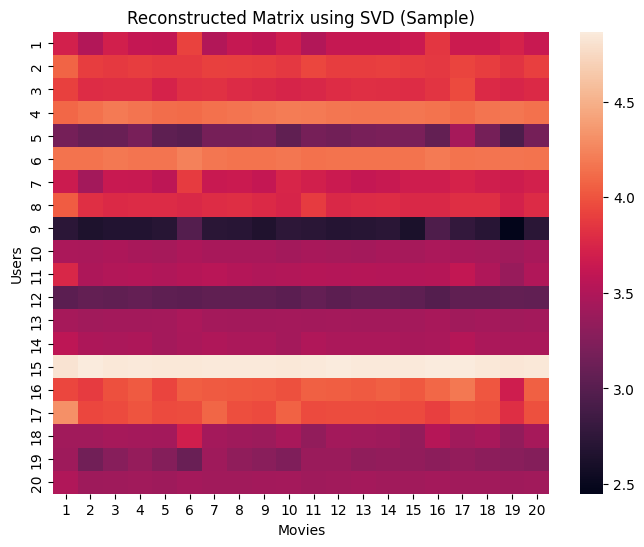

In [16]:
# Take a small sample (first 20 users & 20 movies)
sample_original = user_item_matrix.iloc[:20, :20].fillna(0)
sample_reconstructed = reconstructed_df.iloc[:20, :20]

import matplotlib.pyplot as plt
import seaborn as sns

# Original Matrix
plt.figure(figsize=(8,6))
sns.heatmap(sample_original)
plt.title("Original User-Item Matrix (Sample)")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.show()

# Reconstructed Matrix
plt.figure(figsize=(8,6))
sns.heatmap(sample_reconstructed)
plt.title("Reconstructed Matrix using SVD (Sample)")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.show()

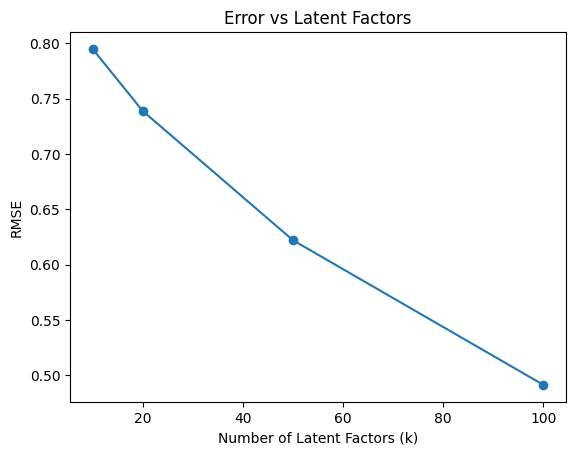

In [17]:
ks = [10, 20, 50, 100]
rmse_list = []

for k in ks:
    U_k = U[:, :k]
    sigma_k = np.diag(sigma[:k])
    Vt_k = Vt[:k, :]

    recon = np.dot(np.dot(U_k, sigma_k), Vt_k)
    recon += user_means.values.reshape(-1, 1)

    pred = recon

    y_pred = pred[mask]
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    rmse_list.append(rmse)

# Plot
plt.figure()
plt.plot(ks, rmse_list, marker='o')
plt.xlabel("Number of Latent Factors (k)")
plt.ylabel("RMSE")
plt.title("Error vs Latent Factors")
plt.show()

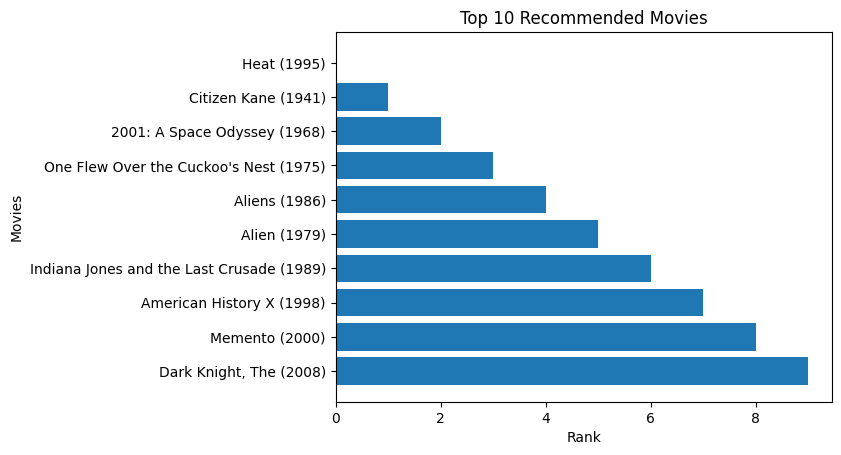

In [18]:
user_id = 1

top_movies = recommend_movies(user_id, 10)

# Merge with titles
top_movies = top_movies[['movieId']].merge(movies, on='movieId')

# Plot
plt.figure()
plt.barh(top_movies['title'], range(len(top_movies)))
plt.xlabel("Rank")
plt.ylabel("Movies")
plt.title("Top 10 Recommended Movies")
plt.gca().invert_yaxis()
plt.show()

# Scenario - 2

In [19]:
movies = pd.read_csv('/kaggle/input/datasets/ayushimishra2809/movielens-dataset/movies.csv')
ratings = pd.read_csv('/kaggle/input/datasets/ayushimishra2809/movielens-dataset/ratings.csv')

ratings = ratings[['userId', 'movieId', 'rating']]

In [20]:
user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')

In [21]:
matrix_filled = user_item_matrix.fillna(0)

In [22]:
k = 20  # latent features

nmf_model = NMF(n_components=k, init='random', random_state=42, max_iter=200)

W = nmf_model.fit_transform(matrix_filled)   # User-feature matrix
H = nmf_model.components_                    # Item-feature matrix

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [23]:
print("User-feature matrix shape:", W.shape)
print("Item-feature matrix shape:", H.shape)

User-feature matrix shape: (668, 20)
Item-feature matrix shape: (20, 10325)


In [24]:
reconstructed = np.dot(W, H)

reconstructed_df = pd.DataFrame(
    reconstructed,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

In [25]:
actual = user_item_matrix.values
predicted = reconstructed_df.values

mask = ~np.isnan(actual)

y_true = actual[mask]
y_pred = predicted[mask]

In [26]:
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("RMSE:", rmse)

RMSE: 2.4639842187622807


In [27]:
def precision_recall_at_k(user_id, k=10, threshold=3.5):
    actual_ratings = user_item_matrix.loc[user_id]
    predicted_ratings = reconstructed_df.loc[user_id]

    # Relevant items (actual)
    relevant = actual_ratings[actual_ratings >= threshold].index

    # Top-K recommended
    recommended = predicted_ratings.sort_values(ascending=False).head(k).index

    # Intersection
    relevant_and_recommended = set(relevant).intersection(set(recommended))

    precision = len(relevant_and_recommended) / k
    recall = len(relevant_and_recommended) / len(relevant) if len(relevant) > 0 else 0

    return precision, recall


# Average over users
precisions, recalls = [], []

for user in user_item_matrix.index[:100]:  # sample users
    p, r = precision_recall_at_k(user, k=10)
    precisions.append(p)
    recalls.append(r)

print("Precision@10:", np.mean(precisions))
print("Recall@10:", np.mean(recalls))

Precision@10: 0.4620000000000001
Recall@10: 0.10705318258407542


In [28]:
def recommend_movies_nmf(user_id, n=10):
    user_ratings = user_item_matrix.loc[user_id]
    user_pred = reconstructed_df.loc[user_id]

    unseen = user_ratings[user_ratings.isna()].index

    recommendations = user_pred[unseen].sort_values(ascending=False)

    return movies[movies['movieId'].isin(recommendations.head(n).index)]

recommend_movies_nmf(1, 10)

,movieId,title,genres
258,293,Léon: The Professional (a.k.a. The Professiona...,Action|Crime|Drama|Thriller
484,541,Blade Runner (1982),Action|Sci-Fi|Thriller
962,1200,Aliens (1986),Action|Adventure|Horror|Sci-Fi
967,1206,"Clockwork Orange, A (1971)",Crime|Drama|Sci-Fi|Thriller
975,1214,Alien (1979),Horror|Sci-Fi
1843,2329,American History X (1998),Crime|Drama
3322,4226,Memento (2000),Mystery|Thriller
3867,4973,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",Comedy|Romance
5004,6874,Kill Bill: Vol. 1 (2003),Action|Crime|Thriller
5328,7361,Eternal Sunshine of the Spotless Mind (2004),Drama|Romance|Sci-Fi


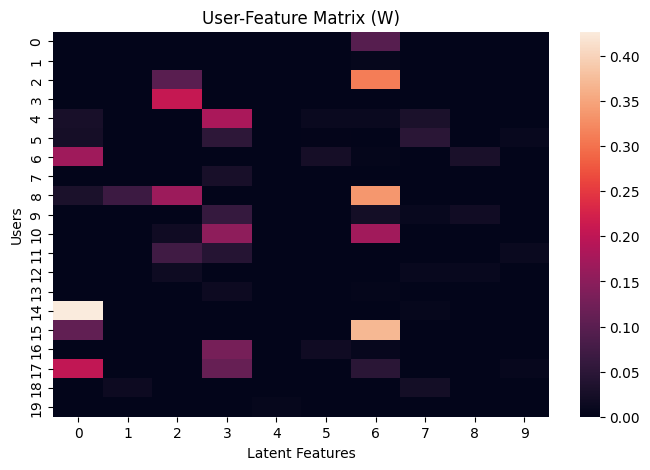

In [29]:
plt.figure(figsize=(8,5))
sns.heatmap(W[:20, :10])
plt.title("User-Feature Matrix (W)")
plt.xlabel("Latent Features")
plt.ylabel("Users")
plt.show()

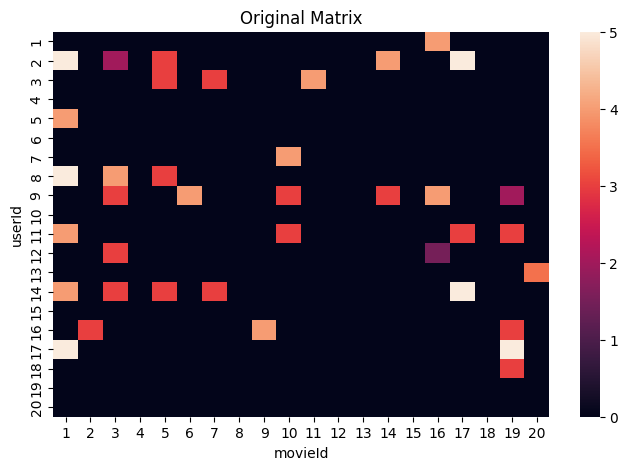

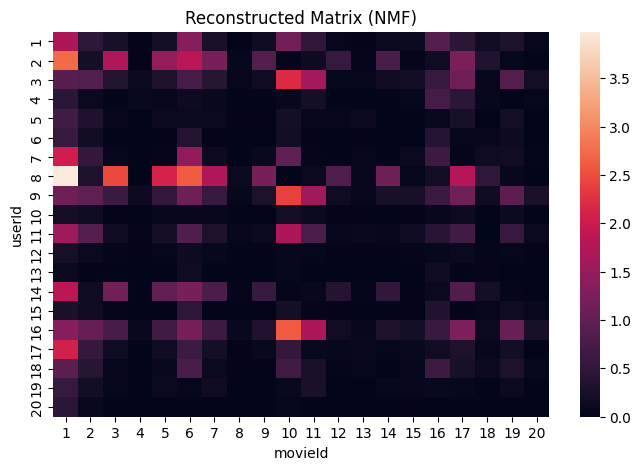

In [30]:
sample_original = user_item_matrix.iloc[:20, :20].fillna(0)
sample_reconstructed = reconstructed_df.iloc[:20, :20]

plt.figure(figsize=(8,5))
sns.heatmap(sample_original)
plt.title("Original Matrix")
plt.show()

plt.figure(figsize=(8,5))
sns.heatmap(sample_reconstructed)
plt.title("Reconstructed Matrix (NMF)")
plt.show()

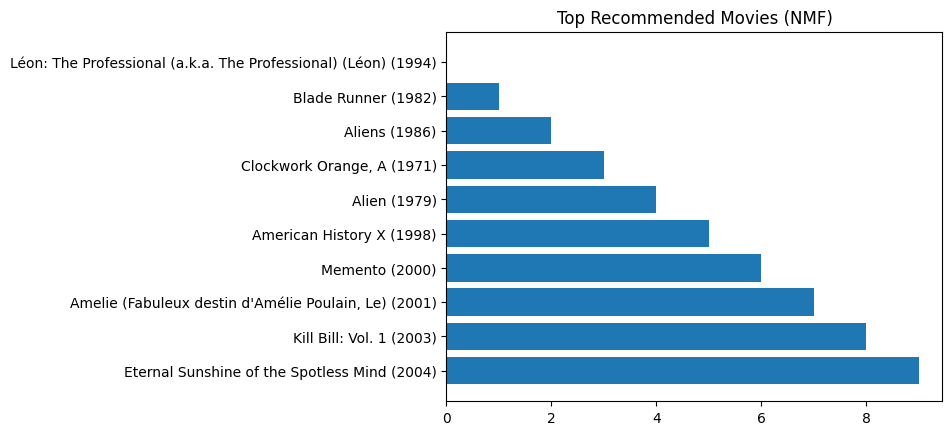

In [31]:
user_id = 1
top_movies = recommend_movies_nmf(user_id, 10)

top_movies = top_movies[['movieId']].merge(movies, on='movieId')

plt.figure()
plt.barh(top_movies['title'], range(len(top_movies)))
plt.gca().invert_yaxis()
plt.title("Top Recommended Movies (NMF)")
plt.show()